# Learned 0D Parameter Comparison

This notebook demonstrates a smaller, but representative workflow that does not include the calibration or forward simulation steps, which require the external binaries `svzerodcalibrator` and `svzerodsolver`.

We start with the standard 0D input file and pre-calibrated 0D input files for a small "proof of concept" dataset containing five aortic geometries. From these, we extract the inputs (geometric features) and outputs (optimal lumped parameters) for the neural network and assign four geometries to a train set and one to a test set. We then train the neural network, and run inference on the unseen test geometry.

We include a bar chart that shows, for each vessel and junction element in the vasculature, the standard, calibrated (optimal), and learned values of Poiseuille resistance **R**, quadratic resistance **S**, and inductance **L**. We see that, even for this small training dataset, the learned values are closer to the optimal ones than the standard values.

The plot compares five parameter sets:

- **Standard** — lumped parameters from the geometric 0D model (vessel dimensions only, no calibration)
- **Calibrated** — optimal parameters from svZeroD calibration against 1D flow data (bundled ground truth)
- **Learned junctions** — neural-network predictions for junction **R**, **S**, and **L** only
- **Learned junctions and vessels** — neural-network predictions for both junction and vessel parameters
- **Learned vessel** — standard junction parameters with vessel **R**, **S**, and **L** replaced by the vessel NN

**Requirements:** `pip install -e ".[dev,notebook]"`, JAX (`jax[cpu]`). Bundled per geometry: `standard-0d` seed JSON, `bifurcations_EL_calibrated_output_BloodVesselJunction.json`, and `oneD/VMR/<geo>/unsteady_soln.vtp` (setup cell). The next section derives `bifurcations_EL_geometric_input.json` from standard-0d + VTP — no svZeroDPlus for that topology step.

Change `SEED` in the setup cell to pick the held-out geometry (4 train / 1 val at 80% split). Examples: `0 → 0154_0001`, `1 → 0175_0000`, `3 → 0129_0000`, `8 → 0176_0000`.


For reference, here is an image of the test geometry with SEED = 0 (0154_0001).

<img src="assets/0154_0001.png" alt="Test geometry 0154_0001 (SEED = 0)" width="80%">


## Setup

Imports, paths, train/val split (`SEED`), and verification of bundled inputs per geometry (standard-0d JSON, calibrated JSON, 1D VTP). See `data/README.md` if files are missing.


In [2]:
from __future__ import annotations

import json
import subprocess
import sys

from IPython.display import Image, display

from learn_lpns import get_pipeline_config, repo_root
from learn_lpns.data_processing.generate_split_indices import generate_geometry_split
from learn_lpns.tools.basic import load_dict
from learn_lpns.visualizations.plot_zero_d_parameter_bars import plot_zero_d_parameter_bars
from learn_lpns.zerod_calibration.modality_paths import (
    NN_JUNCTION_AND_VESSEL_SUFFIX,
    NN_JUNCTION_ONLY_SUFFIX,
    NN_VESSEL_ONLY_SUFFIX,
)
from learn_lpns.zerod_calibration.nn_inference import run_junction_inference, run_vessel_inference

SET_NAME = "VMR_aortas"
RUN_CONFIG = "gen_loss"
GEOMETRY_VARIANT = "bifurcations_EL"
JUNCTION_TYPE = "BloodVesselJunction"
NUM_GEOS = 5
SEED = 0  # change this; examples: 0→0154_0001, 1→0175_0000, 3→0129_0000, 8→0176_0000

GEOMETRIES = sorted(["0129_0000", "0154_0001", "0174_0000", "0175_0000", "0176_0000"])

cfg = get_pipeline_config(set_name=SET_NAME)
percent_train = cfg.split.data_processing_percent_train

train_geos, val_geos = generate_geometry_split(percent_train, SEED, GEOMETRIES)
if len(val_geos) != 1:
    raise ValueError(f"Expected exactly one validation geometry, got {val_geos}")
VAL_GEO = val_geos[0]

print(f"percent_train={percent_train}, seed={SEED}")
print(f"Train ({len(train_geos)}): {train_geos}")
print(f"Val   ({len(val_geos)}): {val_geos}  -> plot target {VAL_GEO}")

ROOT = repo_root()
DATA_ROOT = ROOT / "data"
ZERO_D_BASE = DATA_ROOT / "zeroD" / SET_NAME / RUN_CONFIG
MODEL_DIR = ROOT / "results" / "models" / "notebook_demo" / SET_NAME / f"{GEOMETRY_VARIANT}_trial_{SEED}"
VESSEL_MODEL_DIR = ROOT / "results" / "models" / "notebook_demo" / SET_NAME / f"{GEOMETRY_VARIANT}_vessel_trial_{SEED}"
PLOT_DIR = ROOT / "results" / "notebook_demo" / "param_comparison" / RUN_CONFIG / SET_NAME / f"seed_{SEED}" / VAL_GEO

# Verify bundled inputs (standard-0d + calibrated + 1D VTP)
CALIBRATED_JSON = "calibrated_output_BloodVesselJunction.json"

STANDARD_0D_DIR = DATA_ROOT / "zeroD" / SET_NAME / "standard-0d"
ONE_D_VMR_DIR = DATA_ROOT / "oneD" / "VMR"

missing = []
for geo in GEOMETRIES:
    std_json = STANDARD_0D_DIR / f"{geo}.json"
    if not std_json.is_file():
        missing.append(str(std_json))
    calib_json = ZERO_D_BASE / geo / CALIBRATED_JSON
    if not calib_json.is_file():
        missing.append(str(calib_json))
    centerline_vtp = ONE_D_VMR_DIR / geo / "unsteady_soln.vtp"
    if not centerline_vtp.is_file():
        missing.append(str(centerline_vtp))

if missing:
    raise FileNotFoundError(
        "Missing bundled demo inputs (standard-0d + calibrated JSON + 1D VTP):\n  "
        + "\n  ".join(missing)
        + "\n\nSee data/README.md — these files ship with the repo under data/."
    )

print(f"OK: {len(GEOMETRIES)} geometries × (standard-0d + {CALIBRATED_JSON} + unsteady_soln.vtp)")

percent_train=0.8, seed=0
Train (4): ['0129_0000', '0174_0000', '0175_0000', '0176_0000']
Val   (1): ['0154_0001']  -> plot target 0154_0001
OK: 5 geometries × (standard-0d + calibrated_output_BloodVesselJunction.json + unsteady_soln.vtp)


## 1. Geometric Pre-Processing

Pre-processing steps are applied to the standard 0D files.  First, any junctions with more than two outlets are split into a series for bifurcations.  Next, the junction boundaries are extended into the outlet vessels by pseudo-entrance length to avoid noise caused by local 3D effects common in the splitting zone.

In [3]:
from learn_lpns.zerod_calibration.materialize_bifurcations_el import (
    default_centerline_path,
    materialize_bifurcations_el_from_base,
)

GEO_JSON = "bifurcations_EL_geometric_input.json"

for geo in GEOMETRIES:
    geo_dir = ZERO_D_BASE / geo
    geo_dir.mkdir(parents=True, exist_ok=True)
    centerline = default_centerline_path(DATA_ROOT, geo)

    materialize_bifurcations_el_from_base(
        base_json_path=str(STANDARD_0D_DIR / f"{geo}.json"),
        centerline_path=str(centerline),
        output_bifurcations_el_path=str(geo_dir / GEO_JSON),
        apply_standard_sim_params=True,
        extract_geometric_params=True,
        convert_bifurcations_junctions=True,
        verbose=False,
    )

print(f"Done: built geometric bifurcations_EL input for {len(GEOMETRIES)} geometries.")

  0129_0000: wrote bifurcations_geometric_input.json
  0129_0000: wrote bifurcations_EL_geometric_input.json
  0154_0001: wrote bifurcations_geometric_input.json
  0154_0001: wrote bifurcations_EL_geometric_input.json
  0174_0000: wrote bifurcations_geometric_input.json
  0174_0000: wrote bifurcations_EL_geometric_input.json
  0175_0000: wrote bifurcations_geometric_input.json
  0175_0000: wrote bifurcations_EL_geometric_input.json
  0176_0000: wrote bifurcations_geometric_input.json
  0176_0000: wrote bifurcations_EL_geometric_input.json
Done: built geometric bifurcations_EL input for 5 geometries.


## 2. Calibration

This step generate a 0D input file (json) that contains the calibrated resistances and inductances (R, S, and L) that best reproduce the results of the high-fidelity 3D simulation (projected first onto the 1D centerline (user-provided input), and then onto the 0D nodes (done by learn_lpns)).

This step requires the `svzerodcalibrator` binary so we skip it here and provide the pre-calibrated 0D input file.

## 3. Build Neural Network Training Data 

For each junction and vessel element in each geometry we extract the geometric features (from the centerline geometry) and the ground-truth resistance and inductance values (from the calibrated 0D input file).  These are the inputs and outputs of the neural network.  We organize them into human-readable csvs and jax arrays.  We also split the data into a train and validation set.  All elements from the same geometry belong to the same set.

In [4]:
cmd = [
    sys.executable,
    "-m",
    "learn_lpns.data_processing.run_data_processing",
    "--set_name",
    SET_NAME,
    "--geometry_variant",
    GEOMETRY_VARIANT,
    "--run_config",
    RUN_CONFIG,
    "--percent_train",
    str(percent_train),
    "--seed",
    str(SEED),
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)

jax_path = (
    DATA_ROOT / "jax_arrays" / SET_NAME / RUN_CONFIG / GEOMETRY_VARIANT / "all" / f"jax_arrays_num_geos_{NUM_GEOS}.pkl"
)
split_path = (
    DATA_ROOT
    / "split_indices"
    / SET_NAME
    / RUN_CONFIG
    / GEOMETRY_VARIANT
    / "all"
    / f"train_val_ind_{SET_NAME}_num_geos_{NUM_GEOS}"
)
assert jax_path.is_file(), jax_path
assert split_path.is_file(), split_path
print(f"jax_arrays: {jax_path}")
print(f"split:      {split_path}")

/Users/natalia/cursor_access/learn_lpns/.venv/bin/python -m learn_lpns.data_processing.run_data_processing --set_name VMR_aortas --geometry_variant bifurcations_EL --run_config gen_loss --percent_train 0.8 --seed 0

Processing geometry variant: bifurcations_EL
Auto-discovering geometries with both CSV files for VMR_aortas/bifurcations_EL...
  Found 5 geometries: ['0129_0000', '0154_0001', '0174_0000', '0175_0000', '0176_0000']
Running data processing pipeline for VMR_aortas/bifurcations_EL with 5 geometries
Processing geometry 0129_0000
Loaded 6 junctions with 48 features
Saved features to data/ml_inputs/VMR_aortas/gen_loss/bifurcations_EL/0129_0000/geometric_features.csv
Saved geometric features meta to data/ml_inputs/VMR_aortas/gen_loss/bifurcations_EL/0129_0000/geometric_features_meta.csv
Loaded 6 junctions with 7 target values
  ✓ Consistency check passed: 6 rows — junction names, primary outlets, and outlet_vessel_ids all match
Saved targets to data/ml_inputs/VMR_aortas/gen_loss/b

## 4. Train Neural Networks

Train six neural networks - one each to predict the linear resistance R, quadratic resistance S, and inductance L for both vessel and junction elements.

In [5]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
VESSEL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

junction_cmd = [
    "learn-lpns-train",
    SET_NAME,
    str(NUM_GEOS),
    GEOMETRY_VARIANT,
    "--run_config",
    RUN_CONFIG,
    "--model_dir",
    str(MODEL_DIR),
]
print(" ".join(junction_cmd))
subprocess.run(junction_cmd, cwd=ROOT, check=True)

for i in range(3):
    model_path = MODEL_DIR / f"rri_{SET_NAME}_pred_{i}_model"
    assert model_path.is_file(), model_path
print(f"Junction models saved under {MODEL_DIR}")

vessel_cmd = [
    "learn-lpns-train",
    SET_NAME,
    str(NUM_GEOS),
    GEOMETRY_VARIANT,
    "--run_config",
    RUN_CONFIG,
    "--vessel",
    "--model_dir",
    str(VESSEL_MODEL_DIR),
]
print(" ".join(vessel_cmd))
subprocess.run(vessel_cmd, cwd=ROOT, check=True)

for i in range(3):
    model_path = VESSEL_MODEL_DIR / f"rri_{SET_NAME}_vessel_pred_{i}_model"
    assert model_path.is_file(), model_path
print(f"Vessel models saved under {VESSEL_MODEL_DIR}")

learn-lpns-train VMR_aortas 5 bifurcations_EL --run_config gen_loss --model_dir /Users/natalia/cursor_access/learn_lpns/results/models/notebook_demo/VMR_aortas/bifurcations_EL_trial_0
num_geos: 5

Training junction models for geometry variant: bifurcations_EL
Symmetric loss: overestimate weight = 1.0 for all models
Generation-weighted loss: ON (scale=1; from --generation_weighted_loss and/or --run_config ..._gen_loss)
Training RRI models (one network per coefficient)...
training model 1:  Linear Resistor (R)
19 input features
  asymmetric_loss: OFF  (symmetric loss; overestimate weight = 1.0)
  generation_weighted_loss: ON  (sample weight = 1.0 / 2^generation); generation rows=29
Number of offsets:  1
Number of training points:  24
Number of validation points:  5
Epoch 0 in 1.38 sec  |  Training set accuracy 7.369861e+01  |  Validation set accuracy 2.300473e+02
Epoch 1 in 0.03 sec  |  Training set accuracy 6.452010e+01  |  Validation set accuracy 2.022658e+02
Epoch 2 in 0.03 sec  |  Tr

## 5. Inference
Use the neural network to predict R, S, and L on the unseen test geometry.

In [6]:
val_dir = ZERO_D_BASE / VAL_GEO
geom_json = val_dir / "bifurcations_EL_geometric_input.json"
nn_json = val_dir / f"{GEOMETRY_VARIANT}_NN_{NN_JUNCTION_ONLY_SUFFIX}.json"
nn_junction_and_vessel_json = val_dir / f"{GEOMETRY_VARIANT}_NN_{NN_JUNCTION_AND_VESSEL_SUFFIX}.json"
nn_vessel_only_json = val_dir / f"{GEOMETRY_VARIANT}_NN_{NN_VESSEL_ONLY_SUFFIX}.json"

with open(geom_json) as f:
    nn_config = json.load(f)

jax_data = load_dict(str(jax_path))
run_junction_inference(
    jax_data_dict=jax_data,
    nn_config=nn_config,
    set_name=SET_NAME,
    geo_name=VAL_GEO,
    model_dir=str(MODEL_DIR),
    junction_type=JUNCTION_TYPE,
    quadratic_resistor=False,
)

with open(nn_json, "w") as f:
    json.dump(nn_config, f, indent=4)
print(f"Wrote {nn_json}")

with open(nn_json) as f:
    junction_nn_config = json.load(f)
junction_and_vessel_config, vessel_only_config = run_vessel_inference(
    junction_nn_config=junction_nn_config,
    variant_geometric_input=str(geom_json),
    set_name=SET_NAME,
    geometry_variant=GEOMETRY_VARIANT,
    model_dir=str(MODEL_DIR),
    quadratic_resistor=False,
    verbose=True,
)

with open(nn_junction_and_vessel_json, "w") as f:
    json.dump(junction_and_vessel_config, f, indent=4)
with open(nn_vessel_only_json, "w") as f:
    json.dump(vessel_only_config, f, indent=4)
print(f"Wrote {nn_junction_and_vessel_json}")
print(f"Wrote {nn_vessel_only_json}")

  Loaded 5 feature rows for 4 unique junctions
  Junction names: ['J0_bif3', 'J0_bif0', 'J0_bif2', 'J0_bif1']
  Selected 19 features (matching training data): ['inlet_max_inscribed_radius', 'outlet0_max_inscribed_radius_local', 'outlet0_max_inscribed_radius_min_on_path', 'outlet0_max_inscribed_radius_max_on_path', 'outlet0_rmin_rat', 'outlet0_rmax_rat', 'outlet0_path_length', 'outlet0_tortuosity', 'outlet0_angle_diff', 'outlet0_radius_ratio', 'outlet0_poiseuille_resistance_calc', 'outlet0_inductance_calc', 'outlet0_absorbed_R_poiseuille', 'outlet0_absorbed_L', 'outlet0_absorbed_stenosis_coefficient', 'flow_split_inv', 'outlet0_rneg4', 'outlet0_rneg2', 'outlet0_nd_length']
  Neural network input dimensions: (5, 19) (rows=5, features=19)
      Loading model 1/3: /Users/natalia/cursor_access/learn_lpns/results/models/notebook_demo/VMR_aortas/bifurcations_EL_trial_0/rri_VMR_aortas_pred_0_model
      Loading model 2/3: /Users/natalia/cursor_access/learn_lpns/results/models/notebook_demo/VMR

### Zero-D Parameter Comparison Plot
Visualization showing a comparison of the R, S, and L values for each junction and vessel in the test geometry, as defined the standard, calibrated, and learned 0D model input files.  We see that, even with this small dataset, the learned values are closer to the calibrated (ground truth values) than the standard values are, indicating that they match the 3D solution better.

  ✓ Saved zero-D parameter bar chart to: /Users/natalia/cursor_access/learn_lpns/results/notebook_demo/param_comparison/gen_loss/VMR_aortas/seed_0/0154_0001/bifurcations_EL_zero_d_parameter_bars.png


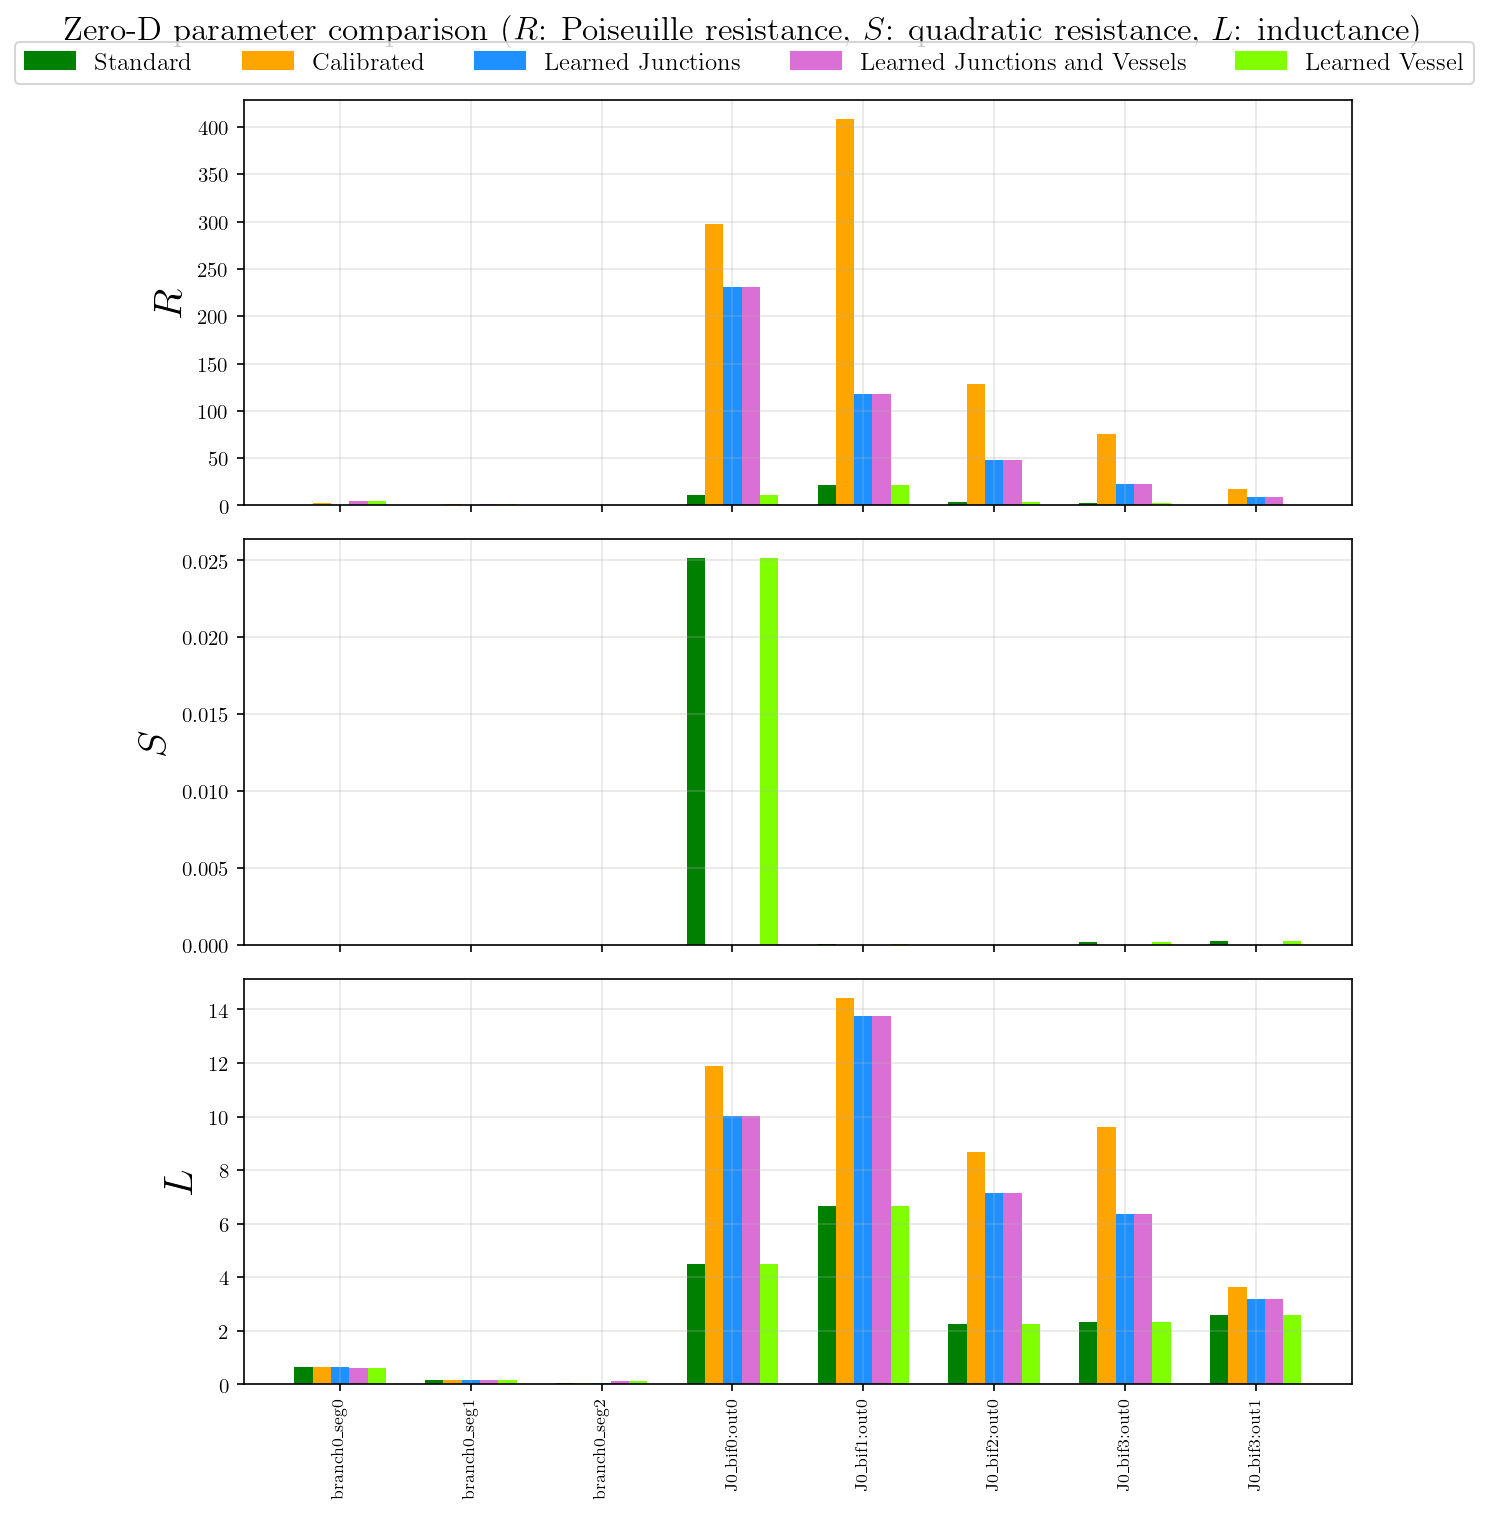

In [7]:
modality_json_paths = {
    "geometric": str(geom_json),
    JUNCTION_TYPE: str(val_dir / "bifurcations_EL_calibrated_output_BloodVesselJunction.json"),
    "BloodVesselJunction_NN": str(nn_json),
    "BloodVesselJunction_NN_plus_Vessel_NN": str(nn_junction_and_vessel_json),
    "Vessel_NN": str(nn_vessel_only_json),
}

PLOT_DIR.mkdir(parents=True, exist_ok=True)
plot_path = plot_zero_d_parameter_bars(
    modality_json_paths,
    output_dir=str(PLOT_DIR),
    output_name=f"{GEOMETRY_VARIANT}_zero_d_parameter_bars.png",
    verbose=True,
)

if plot_path:
    display(Image(filename=plot_path))
else:
    print("Plot generation failed — check modality JSON paths.")

## 6. Forward 0D Simulation

At this point, we can run 0D forward simulation on the standard 0D model, calibrated 0D model, and learned 0D model, and compare the results to the 3D reference.  We expect the calibrated model to match the 3D solution the best, followed by the learned model, and then the standard model.

Forward simulation requires svzerodsolver, so we skip this and load an pre-made plot showing the 0D simulation results (flow and pressure over time) for the different simulation modalities.

![3D vs 0D solutions at vasculature inlet](assets/INFLOW_branch0_inlet_comparison.png)
